In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
features_final = pd.read_csv("../../data/extracted_features_baseline_mean.csv")
train_groups = ['a', 'b', 'c', 'd']
train_features = features_final[features_final['group_id'].isin(train_groups)]
testing_features = features_final[features_final['group_id']== "e"]
feature_cols = ["Asymmetry", "Compactness", "Convexity", "Multicolor", "red_pixels", "blue_pixels", "mean_red", "mean_blue", "Entropy", "Hue_Var", "Sat_Var", "Val_Var","2_3_lesions"]

train_df = train_features[feature_cols + ["Class"]].copy()
train_df["label"] = train_df["Class"].astype(int)
train_df = train_df.drop(columns=["Class"])


In [2]:
#Extract X, y, and groups (for GroupKFold)
# Training data (groups a–d)
X_train = train_features[feature_cols].values
y_train = train_features["Class"].astype(int).values
groups_train = train_features["group_id"].values   # a, b, c, d

# Testing data (group e)
X_test = testing_features[feature_cols].values
y_test = testing_features["Class"].astype(int).values

In [3]:
#kNN model
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import Pipeline

# Base model
knn = KNeighborsClassifier()

# STEP 2: Build the pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),  # Step 1: scale features for kNN
    ("feature_selector", SequentialFeatureSelector(
        knn,
        direction="forward",        # add features one by one
        n_features_to_select="auto" # will be overridden by GridSearchCV
    )),
    ("knn", knn)                   # Step 3: the actual classifier
])


In [4]:
# Fit the pipeline on your training data
pipe.fit(X_train, y_train)

# Extract the feature selector
selector = pipe.named_steps["feature_selector"]

# Boolean mask of selected features
mask = selector.get_support()

# Print selected feature names
selected_features = [f for f, m in zip(feature_cols, mask) if m]
print("Selected features:", selected_features)


Selected features: ['Convexity', 'Multicolor', 'mean_blue', 'Hue_Var', 'Sat_Var', '2_3_lesions']


In [5]:
# STEP 3: Define the hyperparameter grid for GridSearchCV

param_grid = {
    "feature_selector__n_features_to_select": [4, 6, 8, 10, 12],
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}


In [6]:
from sklearn.model_selection import GroupKFold, GridSearchCV

# STEP 4: GroupKFold cross-validation
cv = GroupKFold(n_splits=4)   # because you have groups a, b, c, d

# STEP 5: GridSearchCV with medical scoring
grid = GridSearchCV(
    estimator=pipe,                 # your pipeline from Step 2
    param_grid=param_grid,          # your grid from Step 3
    cv=cv,                          # GroupKFold
    scoring="f1",                   # medical: balances FN and FP
    n_jobs=-1,                      # use all CPU cores
    verbose=2                       # print progress
)

# Fit on training groups (a–d)
grid.fit(X_train, y_train, groups=groups_train)

print("Best parameters:", grid.best_params_)
print("Best CV F1 score:", grid.best_score_)


Fitting 4 folds for each of 120 candidates, totalling 480 fits
[CV] END feature_selector__n_features_to_select=4, knn__metric=euclidean, knn__n_neighbors=3, knn__weights=uniform; total time=   0.7s
[CV] END feature_selector__n_features_to_select=4, knn__metric=euclidean, knn__n_neighbors=3, knn__weights=distance; total time=   0.7s
[CV] END feature_selector__n_features_to_select=4, knn__metric=euclidean, knn__n_neighbors=3, knn__weights=uniform; total time=   0.7s
[CV] END feature_selector__n_features_to_select=4, knn__metric=euclidean, knn__n_neighbors=3, knn__weights=distance; total time=   0.7s
[CV] END feature_selector__n_features_to_select=4, knn__metric=euclidean, knn__n_neighbors=3, knn__weights=uniform; total time=   0.7s
[CV] END feature_selector__n_features_to_select=4, knn__metric=euclidean, knn__n_neighbors=3, knn__weights=uniform; total time=   0.7s
[CV] END feature_selector__n_features_to_select=4, knn__metric=euclidean, knn__n_neighbors=3, knn__weights=distance; total ti

In [7]:
best_pipe = grid.best_estimator_

selector = best_pipe.named_steps["feature_selector"]
mask = selector.get_support()

selected_features = [f for f, m in zip(feature_cols, mask) if m]
print("Selected features:", selected_features)
print("Number of selected features:", sum(mask))

print("All final parameters:")
for param, value in best_pipe.get_params().items():
    print(param, ":", value)

print("Best hyperparameters:", grid.best_params_)

# Example: probability for class 1
probs = best_pipe.predict_proba(X_train)[:, 1]
print("Example probabilities:", probs[:10])

print(best_pipe)


Selected features: ['Convexity', 'Multicolor', 'mean_blue', '2_3_lesions']
Number of selected features: 4
All final parameters:
memory : None
steps : [('scaler', StandardScaler()), ('feature_selector', SequentialFeatureSelector(estimator=KNeighborsClassifier(),
                          n_features_to_select=4)), ('knn', KNeighborsClassifier(metric='euclidean', n_neighbors=15, weights='distance'))]
transform_input : None
verbose : False
scaler : StandardScaler()
feature_selector : SequentialFeatureSelector(estimator=KNeighborsClassifier(),
                          n_features_to_select=4)
knn : KNeighborsClassifier(metric='euclidean', n_neighbors=15, weights='distance')
scaler__copy : True
scaler__with_mean : True
scaler__with_std : True
feature_selector__cv : 5
feature_selector__direction : forward
feature_selector__estimator__algorithm : auto
feature_selector__estimator__leaf_size : 30
feature_selector__estimator__metric : minkowski
feature_selector__estimator__metric_params : None
fe

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

def print_metrics(y_test, y_pred, y_prob):
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"AUC: {auc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1 Score: {f1:.4f}")

print_metrics(y_test, y_pred, y_prob)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.5282
Recall: 0.6154
AUC: 0.5239
Precision: 0.5430
F1 Score: 0.5769
Confusion Matrix:
[[ 77 101]
 [ 75 120]]

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.43      0.47       178
           1       0.54      0.62      0.58       195

    accuracy                           0.53       373
   macro avg       0.52      0.52      0.52       373
weighted avg       0.53      0.53      0.52       373


AUC: 0.5239412273120138


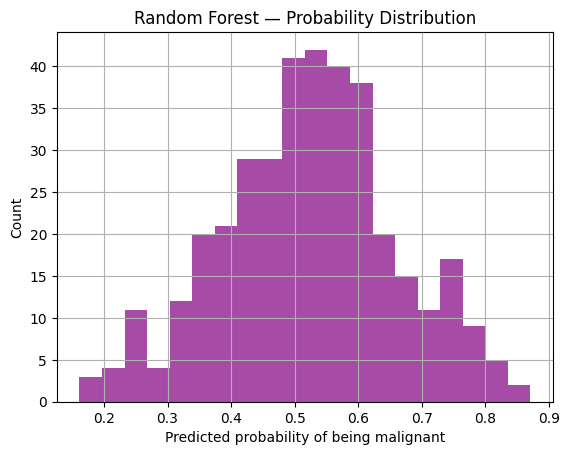

In [9]:
import matplotlib.pyplot as plt

plt.hist(y_prob, bins=20, color='purple', alpha=0.7)
plt.xlabel("Predicted probability of being malignant")
plt.ylabel("Count")
plt.title("Random Forest — Probability Distribution")
plt.grid(True)
plt.show()


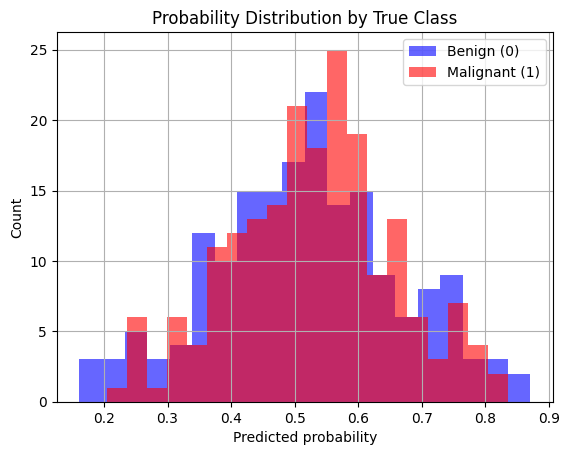

In [10]:
malignant_probs = y_prob[y_test == 1]
benign_probs = y_prob[y_test == 0]

plt.hist(benign_probs, bins=20, alpha=0.6, label="Benign (0)", color="blue")
plt.hist(malignant_probs, bins=20, alpha=0.6, label="Malignant (1)", color="red")

plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Probability Distribution by True Class")
plt.legend()
plt.grid(True)
plt.show()